# Trajectory Classification with 1D CNN - Unshuffled + All Data

In [ ]:
missing_packages = []
try:
    import numpy as np
    print(f"✓ NumPy {np.__version__}")
except ImportError:
    missing_packages.append("numpy")
    print("✗ NumPy not installed")

try:
    import torch
    print(f"✓ PyTorch {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
except ImportError:
    missing_packages.append("torch")
    print("✗ PyTorch not installed")

try:
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__}")
except ImportError:
    missing_packages.append("scikit-learn")
    print("✗ scikit-learn not installed")

try:
    import matplotlib.pyplot as plt
    print(f"✓ matplotlib")
except ImportError:
    missing_packages.append("matplotlib")
    print("✗ matplotlib not installed")

if missing_packages:
    print(f"\n⚠️  MISSING PACKAGES: {', '.join(missing_packages)}")
    print("\nTo install, run this in a terminal:")
    print(f"  pip install {' '.join(missing_packages)}")
    print("\nOr install all at once:")
    print("  pip install torch torchvision scikit-learn matplotlib numpy")
    raise ImportError(f"Please install missing packages: {', '.join(missing_packages)}")

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print("\n✓ All libraries imported successfully!")


✓ NumPy 2.3.3
✓ PyTorch 2.9.0+cpu
  CUDA available: False
✓ scikit-learn 1.7.2
✓ matplotlib

✓ All libraries imported successfully!


In [14]:
data = np.load('pendulum_lqr_50k/trajectory_data.npz')
X = data['X']
y = data['y']
ids = data['ids']

print(f"X shape: {X.shape}  (trajectories, time_steps, features)")
print(f"y shape: {y.shape}  (outcomes)")
print(f"Success rate: {np.mean(y == 1):.2%}")
print(f"Failure rate: {np.mean(y == 0):.2%}")


X shape: (49770, 502, 2)  (trajectories, time_steps, features)
y shape: (49770,)  (outcomes)
Success rate: 38.52%
Failure rate: 61.48%


In [3]:
class CNNTrajectoryClassifier(nn.Module):
    """1D CNN for trajectory classification"""
    def __init__(self, num_classes=1):
        super(CNNTrajectoryClassifier, self).__init__()
        
        # Multiple 1D convolution layers
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=7, padding=3)
        
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)  # Global average pooling
        self.dropout = nn.Dropout(0.3)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # x shape: (batch_size, 502, 2)
        x = x.transpose(1, 2)  # (batch_size, 2, 502)
        
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        
        x = self.pool(x)  # (batch_size, 256, 1)
        x = x.squeeze(-1)  # (batch_size, 256)
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNTrajectoryClassifier(num_classes=1).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized on: {device}")
print(f"Total parameters: {total_params:,}")


Model initialized on: cpu
Total parameters: 287,681


In [13]:
class TrajectoryDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.FloatTensor([self.y[idx]])

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"  Train set: {len(X_train):,} samples")
print(f"  Validation set: {len(X_val):,} samples")
print(f"  Test set: {len(X_test):,} samples")

# Create datasets and loaders
print("\nCreating data loaders...")
train_dataset = TrajectoryDataset(X_train, y_train)
val_dataset = TrajectoryDataset(X_val, y_val)
test_dataset = TrajectoryDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

  Train set: 31,852 samples
  Validation set: 7,964 samples
  Test set: 9,954 samples

Creating data loaders...


In [ ]:
# loss func + optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training func
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predicted = (predictions > 0.5).float()
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    return total_loss / len(train_loader), 100 * correct / total

# validation func
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            
            total_loss += loss.item()
            predicted = (predictions > 0.5).float()
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    all_predictions = np.array(all_predictions).flatten()
    all_labels = np.array(all_labels).flatten()
    
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    
    return total_loss / len(val_loader), accuracy, f1

print("Training setup complete!")


Training setup complete!


In [ ]:
num_epochs = 20
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_f1_scores = []

best_val_f1 = 0
best_model_state = None

print("Starting training...")
print()

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc * 100)
    val_f1_scores.append(val_f1)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%, Val F1: {val_f1:.4f}")
        print()

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model (Validation F1: {best_val_f1:.4f})")


Starting training...

Epoch 1/20
  Train Loss: 0.0082, Train Acc: 99.65%
  Val Loss: 0.0004, Val Acc: 99.99%, Val F1: 0.9998

Epoch 2/20
  Train Loss: 0.0015, Train Acc: 99.95%
  Val Loss: 0.0005, Val Acc: 99.97%, Val F1: 0.9997

Epoch 3/20
  Train Loss: 0.0017, Train Acc: 99.95%
  Val Loss: 0.0006, Val Acc: 99.97%, Val F1: 0.9997

Epoch 4/20
  Train Loss: 0.0014, Train Acc: 99.95%
  Val Loss: 0.0022, Val Acc: 99.91%, Val F1: 0.9989

Epoch 5/20
  Train Loss: 0.0015, Train Acc: 99.96%
  Val Loss: 0.0008, Val Acc: 99.96%, Val F1: 0.9995

Epoch 6/20
  Train Loss: 0.0010, Train Acc: 99.96%
  Val Loss: 0.0002, Val Acc: 99.99%, Val F1: 0.9998

Epoch 7/20
  Train Loss: 0.0011, Train Acc: 99.95%
  Val Loss: 0.0003, Val Acc: 99.99%, Val F1: 0.9998

Epoch 8/20
  Train Loss: 0.0011, Train Acc: 99.96%
  Val Loss: 0.0001, Val Acc: 99.99%, Val F1: 0.9998

Epoch 9/20
  Train Loss: 0.0010, Train Acc: 99.97%
  Val Loss: 0.0005, Val Acc: 99.99%, Val F1: 0.9998

Epoch 10/20
  Train Loss: 0.0009, Train Ac

In [15]:
# test evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        predictions = model(batch_X)
        predicted = (predictions > 0.5).float()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

# calc metrics
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy: {test_acc*100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"        Success  {cm[1,0]:6d}  {cm[1,1]:6d}")


TEST SET RESULTS
Accuracy: 99.95%
Precision: 0.9987
Recall: 1.0000
F1 Score: 0.9993

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure    6114       5
        Success       0    3835


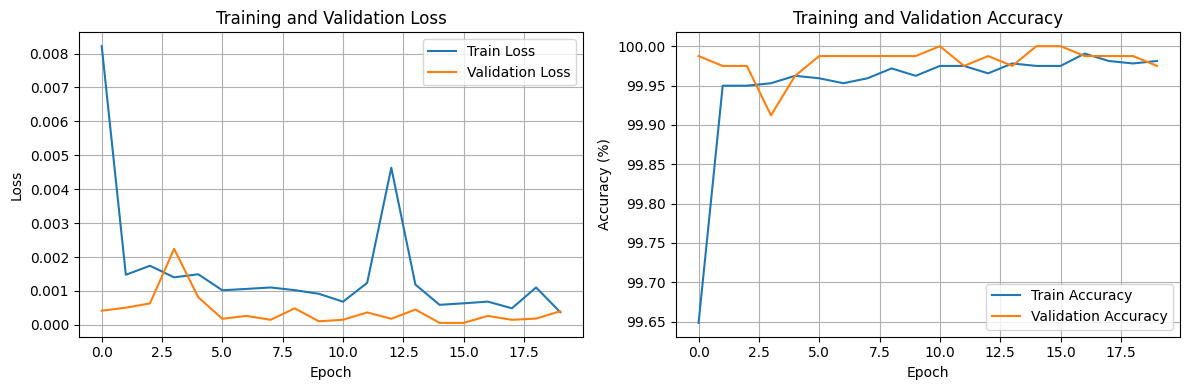

In [ ]:
# training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [12]:
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'num_classes': 1},
}, 'trajectory_classifier_cnn.pth')

print("saved as trajectory_classifier_cnn.pth")


saved as trajectory_classifier_cnn.pth
